### Assignment 5

## Name : Swaraj Patil
## Roll No : 07
## PRN : 12310234
## TY_CSAI-B1


Assignment No. 5 :Learn Decision trees for regression and classification problem

a. Split the data set into training and test sets.
b. Build the decision tree
c. Check model performances on training and test data sets.
d. Apply cost complexity pruning to overcome overfitting problem
e. Apply Random Forest algorithm to overcome overfitting problem.
f. Apply Ada-boost ensemble method on Decision stumps.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

import matplotlib.pyplot as plt




In [2]:
# 1 Load Dataset
data = pd.read_csv("Social_Network_Ads.csv")

print("Dataset Preview")
print(data.head())

print("\nDataset Shape:", data.shape)



Dataset Preview
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Dataset Shape: (400, 5)


In [3]:
# 2 Data Preprocessing

data = data.drop("User ID", axis=1)

encoder = LabelEncoder()
data["Gender"] = encoder.fit_transform(data["Gender"])

print("\nProcessed Dataset")
print(data.head())




Processed Dataset
   Gender  Age  EstimatedSalary  Purchased
0       1   19            19000          0
1       1   35            20000          0
2       0   26            43000          0
3       0   27            57000          0
4       1   19            76000          0


In [4]:
# 3 Split Dataset

X = data.drop("Purchased", axis=1)
y = data["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)



Training size: (300, 3)
Testing size: (100, 3)


In [5]:
# 4 Build Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

print("\nDecision Tree Training Accuracy:",
      accuracy_score(y_train, train_pred))

print("Decision Tree Testing Accuracy:",
      accuracy_score(y_test, test_pred))




Decision Tree Training Accuracy: 0.9966666666666667
Decision Tree Testing Accuracy: 0.85


In [6]:
# 5 Model Performance

print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))





Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.88        63
           1       0.81      0.78      0.79        37

    accuracy                           0.85       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.85      0.85      0.85       100



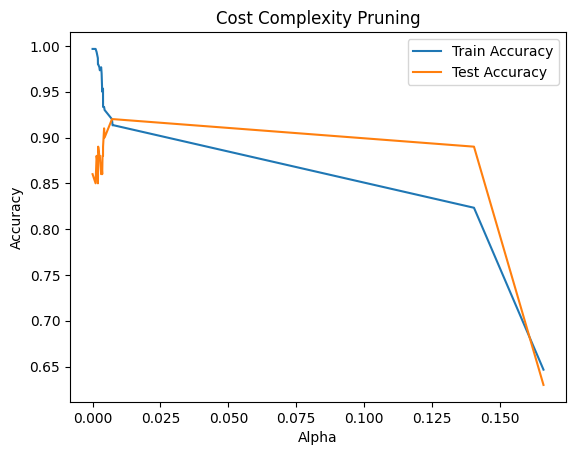

In [7]:
# 6 Cost Complexity Pruning

path = dt_model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

models = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha)
    model.fit(X_train, y_train)
    models.append(model)

train_scores = [m.score(X_train, y_train) for m in models]
test_scores = [m.score(X_test, y_test) for m in models]

plt.plot(ccp_alphas, train_scores, label="Train Accuracy")
plt.plot(ccp_alphas, test_scores, label="Test Accuracy")
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Cost Complexity Pruning")
plt.show()



In [8]:
# 7 Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Accuracy:",
      accuracy_score(y_test, rf_pred))



Random Forest Accuracy: 0.89


In [9]:
# 8 AdaBoost with Decision Stumps

ada_model = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)

print("\nAdaBoost Accuracy:",
      accuracy_score(y_test, ada_pred))


AdaBoost Accuracy: 0.9
